In [5]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ cho đẹp
sns.set_theme(style="whitegrid")

In [6]:
def parse_hdfs_log(path):
    print("Đang đọc file log, vui lòng đợi...")
    records = []
    # RegEx tìm chuỗi có định dạng blk_ kèm các chữ số
    pattern = re.compile(r'(blk_-?\d+)')
    
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            blocks = pattern.findall(line)
            # Dùng set() để tránh trùng lặp blk trên cùng 1 dòng
            for blk in set(blocks):
                records.append({'BlockId': blk, 'Content': line.strip()})
            
            # In tiến độ mỗi 1 triệu dòng
            if (i + 1) % 1000000 == 0:
                print(f"Đã xử lý {i + 1} dòng...")
                
    df = pd.DataFrame(records)
    print(f"Hoàn tất! Tổng số bản ghi tìm thấy: {len(df)}")
    return df

# Gọi hàm đọc dữ liệu (đảm bảo đường dẫn đúng với thư mục máy bạn)
df_raw = parse_hdfs_log('../data/HDFS.log')

Đang đọc file log, vui lòng đợi...
Đã xử lý 1000000 dòng...
Đã xử lý 2000000 dòng...
Đã xử lý 3000000 dòng...
Đã xử lý 4000000 dòng...
Đã xử lý 5000000 dòng...
Đã xử lý 6000000 dòng...
Đã xử lý 7000000 dòng...
Đã xử lý 8000000 dòng...
Đã xử lý 9000000 dòng...
Đã xử lý 10000000 dòng...
Đã xử lý 11000000 dòng...
Hoàn tất! Tổng số bản ghi tìm thấy: 11175629


In [7]:
print("Đang gom nhóm log theo BlockId...")
# Gom nhóm tất cả Content có chung BlockId thành một danh sách (list)
sessions = df_raw.groupby('BlockId')['Content'].apply(list).reset_index()

# Tính độ dài của mỗi session (số lượng dòng log trong block đó)
sessions['Session_Length'] = sessions['Content'].apply(len)

print("Đang gán nhãn Normal/Anomaly...")
# Đọc file label
labels = pd.read_csv('../data/anomaly_label.csv')

# Ghép (merge) nhãn vào tập session
sessions = sessions.merge(labels, on='BlockId')

print("Bảng dữ liệu sau khi xử lý:")
display(sessions.head())

Đang gom nhóm log theo BlockId...
Đang gán nhãn Normal/Anomaly...
Bảng dữ liệu sau khi xử lý:


,BlockId,Content,Session_Length,Label
0,blk_-1000002529962039464,[081111 094452 25370 INFO dfs.DataNode$DataXce...,13,Normal
1,blk_-100000266894974466,[081110 020106 31 INFO dfs.FSNamesystem: BLOCK...,28,Normal
2,blk_-1000007292892887521,[081111 094715 25843 INFO dfs.DataNode$DataXce...,13,Normal
3,blk_-1000014584150379967,[081110 015117 5887 INFO dfs.DataNode$DataXcei...,29,Normal
4,blk_-1000028658773048709,[081110 221431 15750 INFO dfs.DataNode$DataXce...,19,Normal


C:\Users\Admin\AppData\Local\Temp\ipykernel_33208\1495171119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=sessions, x='Label', palette=['#1f77b4', '#d62728'])


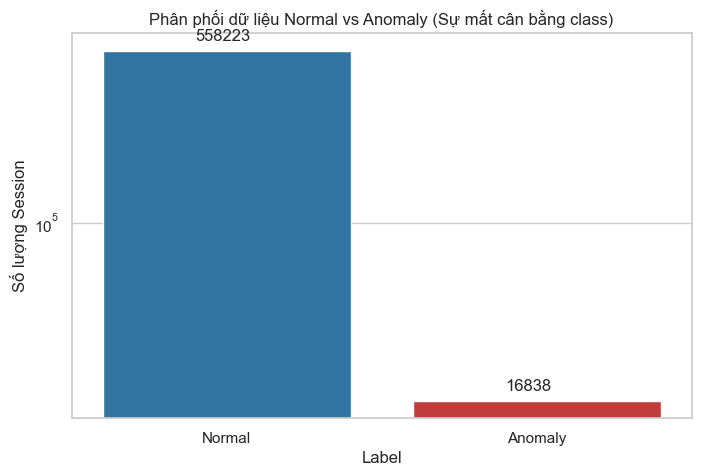

Tỷ lệ Normal : Anomaly = 33.2 : 1


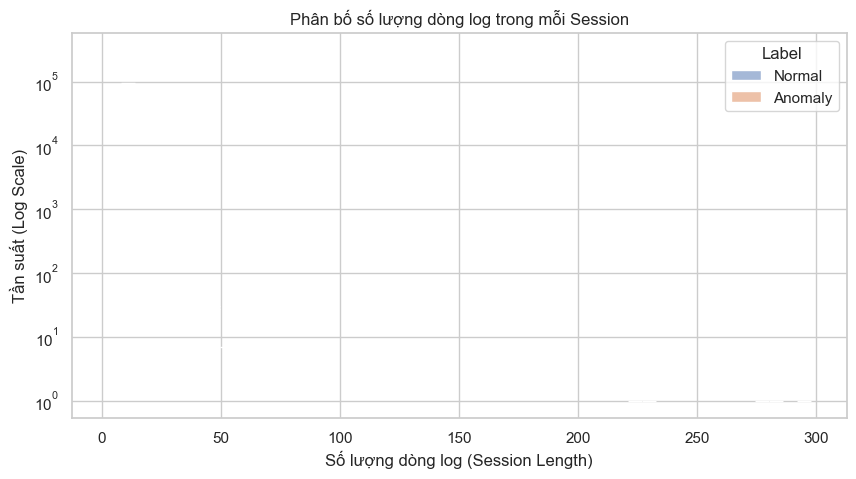

In [8]:
# 1. Vẽ biểu đồ phân phối Nhãn (Class Imbalance)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=sessions, x='Label', palette=['#1f77b4', '#d62728'])
plt.title('Phân phối dữ liệu Normal vs Anomaly (Sự mất cân bằng class)')
plt.ylabel('Số lượng Session')
plt.yscale('log') # Dùng thang đo log vì Normal quá lớn so với Anomaly

# Hiển thị con số cụ thể trên cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() * 1.1))
plt.show()

# In tỷ lệ
normal_count = (sessions['Label'] == 'Normal').sum()
anomaly_count = (sessions['Label'] == 'Anomaly').sum()
print(f"Tỷ lệ Normal : Anomaly = {normal_count/anomaly_count:.1f} : 1")

# 2. Vẽ biểu đồ phân bố độ dài của các Session
plt.figure(figsize=(10, 5))
sns.histplot(data=sessions, x='Session_Length', hue='Label', bins=50, log_scale=(False, True))
plt.title('Phân bố số lượng dòng log trong mỗi Session')
plt.xlabel('Số lượng dòng log (Session Length)')
plt.ylabel('Tần suất (Log Scale)')
plt.show()